In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries loaded successfully!")

All libraries loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv('Resume.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nJob Categories:")
print(df['Category'].value_counts())
df.head(3)

Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

Job Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

print("Text cleaning done!")
print("\nSample cleaned resume (first 200 chars):")
print(df['cleaned_resume'].iloc[0][:200])

Text cleaning done!

Sample cleaned resume (first 200 chars):
administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri


In [5]:
# These are our job descriptions for different roles
# The system will match resumes against these
job_descriptions = {
    'INFORMATION-TECHNOLOGY': """
        python java sql software development programming algorithms
        data structures machine learning cloud aws docker linux
        agile scrum api rest database networking cybersecurity
        debugging testing git version control
    """,
    
    'DATA-SCIENCE': """
        python machine learning deep learning statistics data analysis
        pandas numpy scikit-learn tensorflow pytorch sql tableau
        data visualization feature engineering model training nlp
        regression classification clustering neural networks
    """,
    
    'FINANCE': """
        financial analysis accounting budgeting forecasting excel
        financial modeling investment portfolio risk management
        balance sheet income statement cash flow audit tax
        compliance regulations banking derivatives
    """,
    
    'HR': """
        recruitment hiring onboarding employee relations payroll
        performance management training development hr policies
        talent acquisition workforce planning benefits compensation
        labor law compliance organizational development
    """,
    
    'HEALTHCARE': """
        patient care clinical medical nursing diagnosis treatment
        healthcare management hospital pharmacy surgery medical records
        health insurance billing coding anatomy physiology
        medical terminology patient safety protocols
    """,
    
    'ENGINEERING': """
        mechanical electrical civil structural design autocad
        project management manufacturing quality control
        thermodynamics materials testing prototyping
        technical drawing specifications engineering analysis
    """
}

print(f"Defined {len(job_descriptions)} job roles for matching")
print("Roles:", list(job_descriptions.keys()))

Defined 6 job roles for matching
Roles: ['INFORMATION-TECHNOLOGY', 'DATA-SCIENCE', 'FINANCE', 'HR', 'HEALTHCARE', 'ENGINEERING']


In [6]:
def screen_resumes(target_role, top_n=10):
    
    # Check if role exists
    if target_role not in job_descriptions:
        print(f"Role '{target_role}' not found.")
        print(f"Available roles: {list(job_descriptions.keys())}")
        return None
    
    job_desc = clean_text(job_descriptions[target_role])
    
    # Filter resumes for this category if available
    # Otherwise use all resumes
    if target_role in df['Category'].values:
        role_df = df[df['Category'] == target_role].copy()
    else:
        role_df = df.copy()
    
    role_df = role_df.reset_index(drop=True)
    
    # Combine job description with all resumes for TF-IDF
    all_texts = [job_desc] + list(role_df['cleaned_resume'])
    
    # Vectorize
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    # Calculate similarity between job description and each resume
    job_vector = tfidf_matrix[0]
    resume_vectors = tfidf_matrix[1:]
    similarities = cosine_similarity(job_vector, resume_vectors)[0]
    
    # Add scores to dataframe
    role_df['match_score'] = similarities
    role_df['match_percent'] = (similarities * 100).round(2)
    
    # Assign grades
    def assign_grade(score):
        if score >= 70: return 'Excellent'
        elif score >= 50: return 'Good'
        elif score >= 30: return 'Average'
        else: return 'Below Average'
    
    role_df['grade'] = role_df['match_percent'].apply(assign_grade)
    
    # Rank candidates
    ranked = role_df.sort_values('match_score', ascending=False).head(top_n)
    ranked['rank'] = range(1, len(ranked)+1)
    
    return ranked, vectorizer, job_desc

print("Screening system built successfully!")

Screening system built successfully!


In [7]:
results, vectorizer, job_desc = screen_resumes('INFORMATION-TECHNOLOGY', top_n=10)

print("TOP 10 CANDIDATES FOR INFORMATION-TECHNOLOGY ROLE")
print("=" * 60)
for _, row in results.iterrows():
    print(f"Rank {row['rank']:2d} | Score: {row['match_percent']:5.1f}% | "
          f"Grade: {row['grade']:15s} | ID: {row['ID']}")
print("=" * 60)

TOP 10 CANDIDATES FOR INFORMATION-TECHNOLOGY ROLE
Rank  1 | Score:  25.0% | Grade: Below Average   | ID: 83816738
Rank  2 | Score:  14.5% | Grade: Below Average   | ID: 20824105
Rank  3 | Score:  13.8% | Grade: Below Average   | ID: 70089206
Rank  4 | Score:   9.9% | Grade: Below Average   | ID: 16186411
Rank  5 | Score:   9.6% | Grade: Below Average   | ID: 10641230
Rank  6 | Score:   9.0% | Grade: Below Average   | ID: 18187364
Rank  7 | Score:   8.1% | Grade: Below Average   | ID: 26746496
Rank  8 | Score:   8.1% | Grade: Below Average   | ID: 28697203
Rank  9 | Score:   7.3% | Grade: Below Average   | ID: 13385306
Rank 10 | Score:   6.9% | Grade: Below Average   | ID: 13405733


In [8]:
def get_skill_gap(resume_text, role):
    
    # Key skills for each role
    role_skills = {
        'INFORMATION-TECHNOLOGY': [
            'python', 'java', 'sql', 'linux', 'aws', 'docker',
            'git', 'api', 'database', 'networking', 'agile', 'cloud'
        ],
        'DATA-SCIENCE': [
            'python', 'machine learning', 'statistics', 'pandas',
            'numpy', 'tensorflow', 'sql', 'visualization', 'nlp'
        ],
        'FINANCE': [
            'excel', 'accounting', 'budgeting', 'forecasting',
            'financial modeling', 'risk', 'audit', 'tax', 'compliance'
        ],
        'HR': [
            'recruitment', 'onboarding', 'payroll', 'training',
            'talent', 'compensation', 'compliance', 'workforce'
        ],
        'HEALTHCARE': [
            'patient care', 'clinical', 'medical', 'nursing',
            'pharmacy', 'diagnosis', 'treatment', 'hospital'
        ],
        'ENGINEERING': [
            'autocad', 'design', 'manufacturing', 'quality',
            'mechanical', 'electrical', 'project management', 'testing'
        ]
    }
    
    if role not in role_skills:
        return [], []
    
    required = role_skills[role]
    resume_lower = resume_text.lower()
    
    present = [skill for skill in required if skill in resume_lower]
    missing = [skill for skill in required if skill not in resume_lower]
    
    return present, missing


# Show skill gap for top 3 candidates
print("SKILL GAP ANALYSIS - TOP 3 CANDIDATES")
print("=" * 60)

for i, (_, row) in enumerate(results.head(3).iterrows()):
    present, missing = get_skill_gap(row['Resume_str'], 'INFORMATION-TECHNOLOGY')
    print(f"\nRank {i+1} | Candidate ID: {row['ID']} | Score: {row['match_percent']}%")
    print(f"  Skills Present : {', '.join(present) if present else 'None detected'}")
    print(f"  Skills Missing : {', '.join(missing) if missing else 'None'}")
    print(f"  Recommendation : ", end="")
    if len(missing) == 0:
        print("Strong fit - proceed to interview")
    elif len(missing) <= 3:
        print("Good fit - minor skill gaps, trainable")
    else:
        print("Partial fit - significant skill gaps identified")
print("=" * 60)

SKILL GAP ANALYSIS - TOP 3 CANDIDATES

Rank 1 | Candidate ID: 83816738 | Score: 25.01%
  Skills Present : java, sql, linux, aws, git, api, database, agile, cloud
  Skills Missing : python, docker, networking
  Recommendation : Good fit - minor skill gaps, trainable

Rank 2 | Candidate ID: 20824105 | Score: 14.54%
  Skills Present : python, linux, aws, networking, cloud
  Skills Missing : java, sql, docker, git, api, database, agile
  Recommendation : Partial fit - significant skill gaps identified

Rank 3 | Candidate ID: 70089206 | Score: 13.82%
  Skills Present : java, sql, linux, database
  Skills Missing : python, aws, docker, git, api, networking, agile, cloud
  Recommendation : Partial fit - significant skill gaps identified


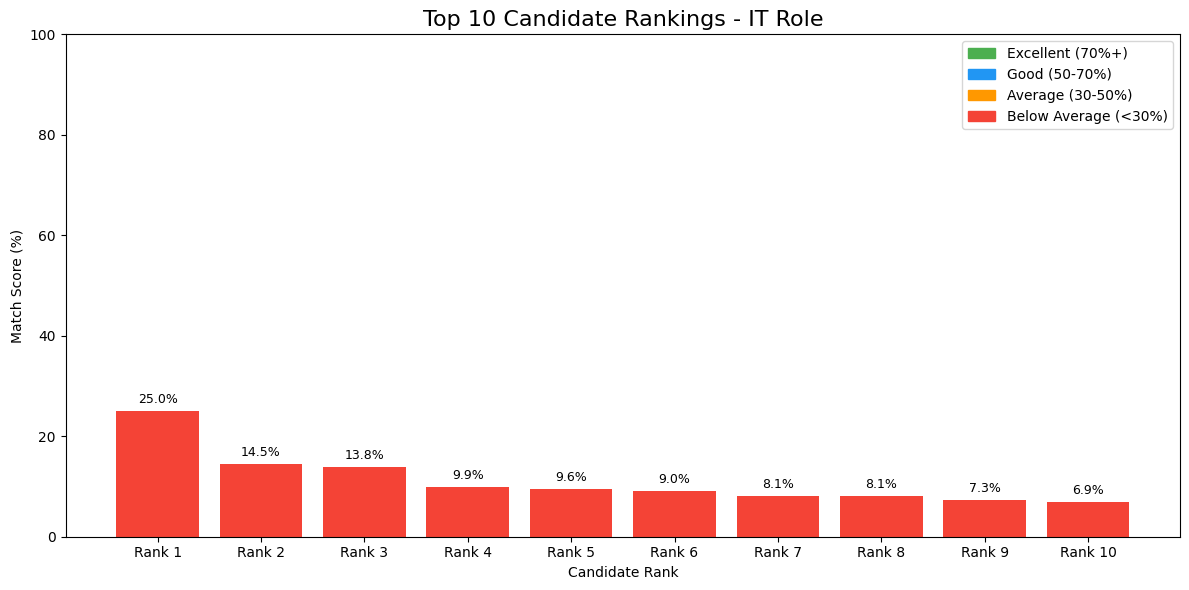

Chart saved!


In [9]:
plt.figure(figsize=(12, 6))
top_results = results.head(10)

colors = []
for grade in top_results['grade']:
    if grade == 'Excellent': colors.append('#4CAF50')
    elif grade == 'Good': colors.append('#2196F3')
    elif grade == 'Average': colors.append('#FF9800')
    else: colors.append('#F44336')

bars = plt.bar(
    [f"Rank {r}" for r in top_results['rank']], 
    top_results['match_percent'],
    color=colors
)

plt.title('Top 10 Candidate Rankings - IT Role', fontsize=16)
plt.xlabel('Candidate Rank')
plt.ylabel('Match Score (%)')
plt.ylim(0, 100)

for bar, score in zip(bars, top_results['match_percent']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.1f}%', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend = [
    Patch(color='#4CAF50', label='Excellent (70%+)'),
    Patch(color='#2196F3', label='Good (50-70%)'),
    Patch(color='#FF9800', label='Average (30-50%)'),
    Patch(color='#F44336', label='Below Average (<30%)')
]
plt.legend(handles=legend, loc='upper right')
plt.tight_layout()
plt.savefig('candidate_rankings.png', dpi=150)
plt.show()
print("Chart saved!")

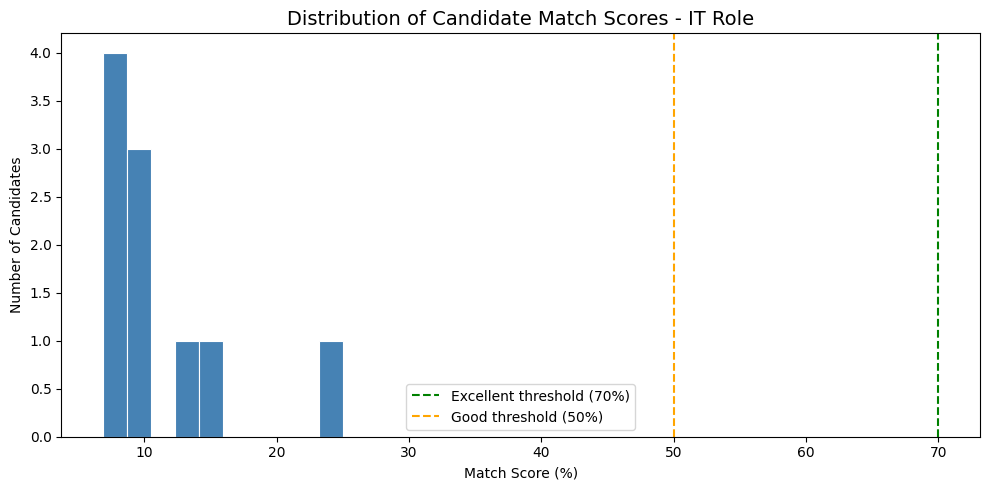

Chart saved!


In [10]:
plt.figure(figsize=(10, 5))
plt.hist(results['match_percent'], bins=10, 
         color='steelblue', edgecolor='white', linewidth=0.8)
plt.title('Distribution of Candidate Match Scores - IT Role', fontsize=14)
plt.xlabel('Match Score (%)')
plt.ylabel('Number of Candidates')
plt.axvline(x=70, color='green', linestyle='--', label='Excellent threshold (70%)')
plt.axvline(x=50, color='orange', linestyle='--', label='Good threshold (50%)')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [11]:
# You can change this to any role from the list below
# INFORMATION-TECHNOLOGY, DATA-SCIENCE, FINANCE, 
# HR, HEALTHCARE, ENGINEERING

test_role = 'FINANCE'
results_finance, _, _ = screen_resumes('FINANCE', top_n=5)

print(f"TOP 5 CANDIDATES FOR {test_role} ROLE")
print("=" * 60)
for _, row in results_finance.iterrows():
    present, missing = get_skill_gap(row['Resume_str'], test_role)
    print(f"\nRank {row['rank']} | Score: {row['match_percent']}% | Grade: {row['grade']}")
    print(f"  Skills Present : {', '.join(present) if present else 'None detected'}")
    print(f"  Skills Missing : {', '.join(missing) if missing else 'None'}")
print("=" * 60)

TOP 5 CANDIDATES FOR FINANCE ROLE

Rank 1 | Score: 24.19% | Grade: Below Average
  Skills Present : excel, accounting, budgeting, forecasting, risk, audit, compliance
  Skills Missing : financial modeling, tax

Rank 2 | Score: 17.43% | Grade: Below Average
  Skills Present : excel, accounting, budgeting, forecasting, financial modeling, risk, audit, compliance
  Skills Missing : tax

Rank 3 | Score: 16.59% | Grade: Below Average
  Skills Present : excel, accounting, budgeting, forecasting, risk, audit, tax, compliance
  Skills Missing : financial modeling

Rank 4 | Score: 14.1% | Grade: Below Average
  Skills Present : excel, accounting, budgeting, forecasting, financial modeling, risk, audit, tax, compliance
  Skills Missing : None

Rank 5 | Score: 13.75% | Grade: Below Average
  Skills Present : excel, accounting, budgeting, forecasting, audit, tax
  Skills Missing : financial modeling, risk, compliance


In [12]:
print(""" RESUME SCREENING SYSTEM REPORT

This system reads resume text and automatically scores and ranks candidates based on how well they match a given job
role. It was built using 2,484 real resumes across 24 job categories. For this demonstration, the system was run
against the Information Technology and Finance roles.

Working: Each resume goes through text cleaning to remove noise, links and irrelevant characters. The cleaned text is then
converted into numbers using TF-IDF, which captures how relevant each word is to the job description. Cosine
similarity is then used to measure how closely a resume matches the job description. The result is a match score
between 0 and 100 percent.

Ranking: Candidates rank higher when their resume contains more of the keywords and skills that appear in the job description.
A candidate who mentions Python, SQL, cloud, and networking will score higher for an IT role than one who only mentions
one or two of those terms. The system rewards both the presence and the frequency of relevant skills.


Also, for each candidate the system checks their resume against a predefined list of key skills for that role. Any skill
not found in the resume is flagged as missing. This helps recruiters quickly see what a candidate would need to learn
or what training would be required before they are fully ready for the role.

Application: Instead of reading hundreds of resumes manually, a recruiter can run this system and get a ranked shortlist in seconds.
The scores, grades and skill gap analysis give enough context to make a confident decision about who to call for an
interview and who needs more development first.

Data source: Resume Dataset, Kaggle
""")

 RESUME SCREENING SYSTEM REPORT

This system reads resume text and automatically scores and ranks candidates based on how well they match a given job
role. It was built using 2,484 real resumes across 24 job categories. For this demonstration, the system was run
against the Information Technology and Finance roles.

Working: Each resume goes through text cleaning to remove noise, links and irrelevant characters. The cleaned text is then
converted into numbers using TF-IDF, which captures how relevant each word is to the job description. Cosine
similarity is then used to measure how closely a resume matches the job description. The result is a match score
between 0 and 100 percent.

Ranking: Candidates rank higher when their resume contains more of the keywords and skills that appear in the job description.
A candidate who mentions Python, SQL, cloud, and networking will score higher for an IT role than one who only mentions
one or two of those terms. The system rewards both the presenc